# Baseline
Here is provided the entire procedure of the baseline provided in the Common Code of the repository provided for the project

### Imports

In [21]:
import torch
import cv2
import torch.nn as nn
import numpy as np
from ultralytics import YOLO
from transformers import pipeline, ViTModel
from PIL import Image
import matplotlib.pyplot as plt
import time
import torch.nn.functional as F

## Classifier
This section contains two types of classifier, one commented, because not good for the baseline, that is about a ViT Classifier, and second one that is a fine tuned ResNet-18 classifier

In [22]:
class ROIClassifierViT(nn.Module):
    def __init__(self, num_hoi_classes):
        super().__init__()

        self.first = nn.Conv2d(
            5, 4, kernel_size=1, stride=1, padding=0, bias=False
        )

        self.pre_conv = nn.Conv2d(
            4, 3, kernel_size=1, stride=1, padding=0, bias=False
        )

        self.backbone = ViTModel.from_pretrained(
            "google/vit-base-patch16-224"
        )

        self.fc = nn.Linear(768, num_hoi_classes)

    def forward(self, x):
        x = self.first(x)
        x = self.pre_conv(x)

        outputs = self.backbone(pixel_values=x)
        features = outputs.last_hidden_state[:, 0]

        return self.fc(features)


def remap_vit_state_dict(old_state_dict):
    new_state_dict = {}

    replacements = [
        (".attention.attention.query.", ".attention.q_proj."),
        (".attention.attention.key.",   ".attention.k_proj."),
        (".attention.attention.value.", ".attention.v_proj."),
        (".attention.output.dense.",    ".attention.o_proj."),
        (".intermediate.dense.",        ".mlp.fc1."),
        (".output.dense.",              ".mlp.fc2."),
        (".encoder.layer.",             ".layers."),
    ]

    for key, value in old_state_dict.items():
        new_key = key
        for old_name, new_name in replacements:
            new_key = new_key.replace(old_name, new_name)
        new_state_dict[new_key] = value

    return new_state_dict

In [23]:

'''

class ROIClassifier(nn.Module):
    def __init__(self, num_hoi_classes):
        super().__init__()
      
        self.first = nn.Conv2d(5, 4, kernel_size=1, stride=1, padding=0, bias=False)
        self.pre_conv = nn.Conv2d(4, 3, kernel_size=1, stride=1, padding=0, bias=False)
        
        self.backbone = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Identity()
        
        self.fc = nn.Linear(512, num_hoi_classes)
        
    def forward(self, x):
        
        x = self.first(x)
        x = self.pre_conv(x)         
        features = self.backbone(x)   
        out = F.sigmoid(self.fc(features))
        return out
    
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
      
        self.encoder = nn.Sequential(
            nn.Conv2d(4, 4, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.Conv2d(4, 4, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.Conv2d(4, 4, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.Conv2d(4, 3, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(),
        )
        
        self.decoder = nn.Sequential(
            nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.ConvTranspose2d(3, 4, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(4),
        )
        
        
    def forward(self, x):
        en = self.encoder(x)
        out = self.decoder(en)
  
        return out

'''

'\n\nclass ROIClassifier(nn.Module):\n    def __init__(self, num_hoi_classes):\n        super().__init__()\n\n        self.first = nn.Conv2d(5, 4, kernel_size=1, stride=1, padding=0, bias=False)\n        self.pre_conv = nn.Conv2d(4, 3, kernel_size=1, stride=1, padding=0, bias=False)\n\n        self.backbone = models.resnet18(pretrained=True)\n        self.backbone.fc = nn.Identity()\n\n        self.fc = nn.Linear(512, num_hoi_classes)\n\n    def forward(self, x):\n\n        x = self.first(x)\n        x = self.pre_conv(x)         \n        features = self.backbone(x)   \n        out = F.sigmoid(self.fc(features))\n        return out\n\nclass AutoEncoder(nn.Module):\n    def __init__(self):\n        super().__init__()\n\n        self.encoder = nn.Sequential(\n            nn.Conv2d(4, 4, kernel_size=3, stride=1, padding=1, bias=False),\n            nn.BatchNorm2d(4),\n            nn.ReLU(),\n            nn.Conv2d(4, 4, kernel_size=3, stride=1, padding=1, bias=False),\n            nn.Batch

### Functions
This part is about creating functions used inside the original baseline. These functions can be found inside the pipeline.py of the Common Code of the original github.
More in particular, load_yolo_model, yolo_inference, parse_yolo_output are functions regarding the Yolo model. Those have to be modified in order to use Unet (see Baseline+Unet.ipynb).

In [24]:
def load_yolo_model(model_path):
    model = YOLO(model_path, verbose=False)
    return model


def yolo_inference(model, image) -> list[dict]:
    output = model.predict(image, verbose=False)
    detections = parse_yolo_output(output)
    return detections


def found_objects(tool_list, tti_list, classes):
    tool_found = []
    tti_found = []
    
    for elem in range(len(classes)):
        if classes[elem] in tool_list:
            tool_found.append(elem)
        if classes[elem] in tti_list:
            tti_found.append(elem)
            
    return tool_found, tti_found


def parse_yolo_output(result) -> list[dict]:
    r = result[0]
    if len(result[0].boxes.cls) == 0:
        return []
    if len(result[0].boxes.cls) < 2:
        return [
            {
                'class': int(r.boxes.cls[0].cpu().detach().numpy()),
                'mask': r.masks.data[0].cpu().detach().numpy()
            }
        ]
    
    tool_list = list(range(0, 12))
    tti_list = list(range(12, 21))

    classes = r.boxes.cls
    masks = r.masks.data
    
    tool_found, tti_found = found_objects(tool_list, tti_list, classes)

    l = []
    
    if len(tool_found) == 0:
        for idx in tti_found:
            l.append({
                'class': int(r.boxes.cls[idx].cpu().detach().numpy()),
                'mask': r.masks.data[idx].cpu().detach().numpy()
            })
        return l
    
    elif len(tti_found) == 0:
        for idx in tool_found:
            l.append({
                'class': int(r.boxes.cls[idx].cpu().detach().numpy()),
                'mask': r.masks.data[idx].cpu().detach().numpy()
            })
        return l
    
    res = []
    
    for idx_tti in tti_found:
        for idx_tool in tool_found:
            tissue_mask = masks[idx_tti]
            tool_mask = masks[idx_tool]
            
            tti_dict = {
                'class': int(classes[idx_tti].cpu().detach().numpy()),
                'mask': tissue_mask.int().cpu().detach().numpy()
            }
            tool_dict = {
                'class': int(classes[idx_tool].cpu().detach().numpy()),
                'mask': tool_mask.int().cpu().detach().numpy()
            }
            
            already_has_tti = False
            for elem in res:
                if elem['class'] == tti_dict['class'] and np.array_equal(elem['mask'], tti_dict['mask']):
                    already_has_tti = True
                    break
            if not already_has_tti:
                res.append(tti_dict)

            already_has_tool = False
            for elem in res:
                if elem['class'] == tool_dict['class'] and np.array_equal(elem['mask'], tool_dict['mask']):
                    already_has_tool = True
                    break
            if not already_has_tool:
                res.append(tool_dict)

    return res


tool_classes = list(range(0, 12))


def find_tool_tissue_pairs(detections: list[dict]):
    tools = [d for d in detections if d['class'] in tool_classes]
    tissues = [d for d in detections if d['class'] not in tool_classes]
    pairs = []
    for s in tools:
        for o in tissues:
            pairs.append({'tool': s, 'tissue': o})
    return pairs


def extract_union_roi(image, tool_mask, tissue_mask, depth_map=None):
    combined_mask = (tool_mask + tissue_mask).clip(0, 1).astype('uint8')
    x, y, w, h = cv2.boundingRect(combined_mask)
    roi = image[y:y+h, x:x+w]
  
    if depth_map is not None:
        depth_roi = depth_map[y:y+h, x:x+w]
        roi = np.concatenate([roi, depth_roi[..., None]], axis=-1)

    merged_mask = cv2.bitwise_or(tool_mask, tissue_mask)
    merged_mask = merged_mask[y:y+h, x:x+w]
    merged_mask = np.expand_dims(merged_mask, axis=-1)
    
    if merged_mask.shape[0] != roi.shape[0] or merged_mask.shape[1] != roi.shape[1]:
        print("MISMATCH")
        return None

    roi = np.concatenate([roi, merged_mask * 255], axis=-1)
    return roi


def end_to_end_pipeline(image_path, yolo_model, depth_model, tti_classifier, device):
    image_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Immagine non trovata: {image_path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    detections = yolo_inference(yolo_model, image_rgb)

    depth_map = np.array(depth_model(Image.fromarray(image_rgb))["depth"])

    pairs = find_tool_tissue_pairs(detections)

    tti_predictions = []

    for pair in pairs:
        tool_mask = pair['tool']['mask']
        tissue_mask = pair['tissue']['mask']

        roi = extract_union_roi(image_rgb, tool_mask, tissue_mask, depth_map)
        if roi is None:
            continue

        roi_tensor = (
            torch.from_numpy(roi)
            .permute(2, 0, 1)
            .unsqueeze(0)
            .float() / 255.0
        )
        roi_tensor = F.interpolate(
            roi_tensor, size=(224, 224), mode='bilinear', align_corners=False
        ).to(device)

        tti_classifier.eval()
        with torch.no_grad():
            tti_logits = tti_classifier(roi_tensor)
            tti_class = torch.argmax(tti_logits, dim=1).item()
            tti_score = torch.softmax(tti_logits, dim=1).max().item()

        tti_predictions.append({
            'tool': pair['tool'],
            'tissue': pair['tissue'],
            'tti_class': tti_class,
            'tti_score': tti_score
        })

    return detections, tti_predictions


def show_mask_overlay_from_binary_mask(
    image_bgr, binary_mask, alpha=0.5, mask_color=(1.0, 0.0, 0.0)
):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    colored_mask = np.zeros_like(image_rgb)
    colored_mask[..., 0] = mask_color[0]  
    colored_mask[..., 1] = mask_color[1]  
    colored_mask[..., 2] = mask_color[2]  

    overlay = image_rgb.copy()
    indices = binary_mask.astype(bool)
    overlay[indices] = (1 - alpha) * image_rgb[indices] + alpha * colored_mask[indices]

    plt.figure(figsize=(8, 8))
    plt.imshow(overlay)
    plt.axis('off')
    plt.show()
    return cv2.cvtColor((overlay * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

### Model loading

In [25]:
model = load_yolo_model('comparison/01_initial_comparison/Yolo11.pt')

pipe = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=0 if torch.cuda.is_available() else -1
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Loading weights: 100%|██████████| 287/287 [00:00<00:00, 7362.16it/s]


### Image directory

In [26]:
image = 'yolo_dataset/images/test/cholec80video42002_frame000124.png' 

1. Classification with neural network

```text
         immagine
            ↓
         YOLO segmentation
            ↓
         tool + tissue detection
            ↓
         creazione delle coppie tool/tissue
            ↓
         calcolo depth map
            ↓
         ROI = RGB + depth + mask
            ↓
         ROIClassifier
            ↓
         TTI class
```
And this is the version of the pipeline.py of the original github.

In [27]:
tti_class = ROIClassifierViT(2)

checkpoint = torch.load("ViT2.pt", map_location="cpu")
checkpoint = remap_vit_state_dict(checkpoint)

missing, unexpected = tti_class.load_state_dict(
    checkpoint,
    strict=False
)

print("Missing keys (dovrebbero essere solo pooler o niente):")
for k in missing:
    print(k)

print("\nUnexpected keys:")
for k in unexpected:
    print(k)

tti_class.to(device)
tti_class.eval()

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 12829.00it/s]
[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Missing keys (dovrebbero essere solo pooler o niente):

Unexpected keys:


ROIClassifierViT(
  (first): Conv2d(5, 4, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (pre_conv): Conv2d(4, 3, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (backbone): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activati

TTI predictions: [{'tool': {'class': 6, 'mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(448, 640), dtype=int32)}, 'tissue': {'class': 15, 'mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(448, 640), dtype=int32)}, 'tti_class': 1, 'tti_score': 1.0}, {'tool': {'class': 6, 'mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(448, 640), dtype=int32)}, 'tissue': {'class': 15, 'mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
 

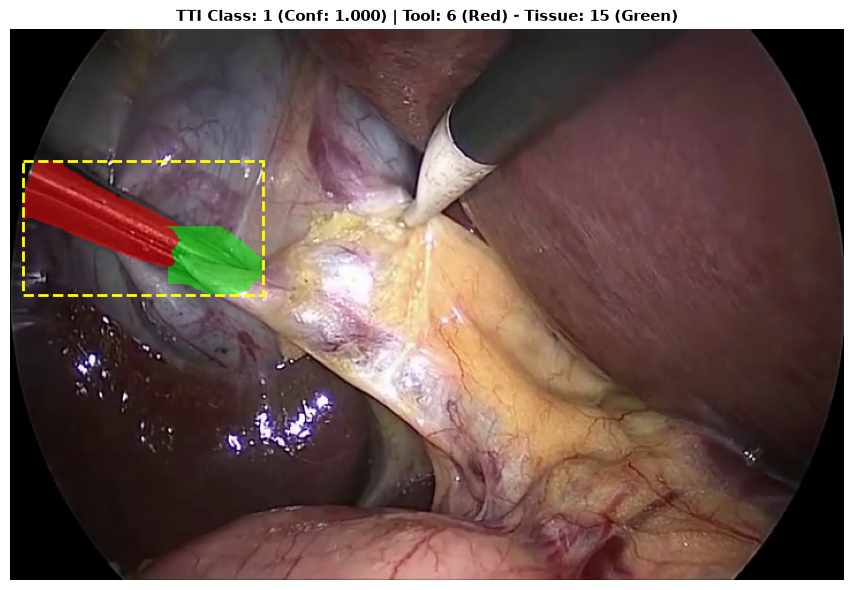


[Coppia 2/2]


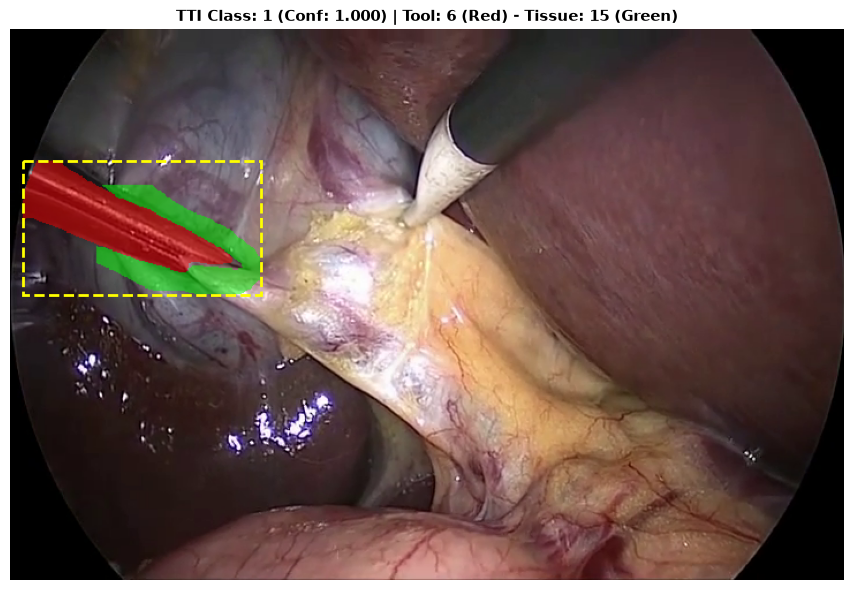

In [28]:
detection, tti_predictions = end_to_end_pipeline(image, model, pipe, tti_class, device)

print("TTI predictions:", tti_predictions)


def visualize_pair(image_bgr, pair_pred, alpha=0.5):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    
    tool_mask = pair_pred['tool']['mask'].astype(bool)
    tissue_mask = pair_pred['tissue']['mask'].astype(bool)
    
    overlay = image_rgb.copy()
    # Sovrapposizione Tool in Rosso
    overlay[tool_mask] = (1 - alpha) * image_rgb[tool_mask] + alpha * np.array([1.0, 0.0, 0.0])
    # Sovrapposizione Tissue in Verde
    overlay[tissue_mask] = (1 - alpha) * image_rgb[tissue_mask] + alpha * np.array([0.0, 1.0, 0.0])
    
    # Calcolo coordinate bounding box ROI
    combined = (pair_pred['tool']['mask'] + pair_pred['tissue']['mask']).clip(0, 1).astype(np.uint8)
    x, y, w, h = cv2.boundingRect(combined)
    
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.imshow(overlay)
    
    # Bounding box giallo tratteggiato che evidenzia la ROI inviata al ViT
    rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor='yellow', linewidth=2, linestyle='--')
    ax.add_patch(rect)
    
    t_class = pair_pred['tool']['class']
    tis_class = pair_pred['tissue']['class']
    tti_c = pair_pred['tti_class']
    tti_s = pair_pred['tti_score']
    
    ax.set_title(f"TTI Class: {tti_c} (Conf: {tti_s:.3f}) | Tool: {t_class} (Red) - Tissue: {tis_class} (Green)", fontsize=11, weight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Esegui la visualizzazione
image_full = cv2.imread(image, cv2.IMREAD_COLOR)
H_full, W_full = image_full.shape[:2]

print(f"--- Totale coppie analizzate: {len(tti_predictions)} ---")

for idx, pred in enumerate(tti_predictions):
    pred_resized = {
        'tool': {
            'class': pred['tool']['class'],
            'mask': cv2.resize(pred['tool']['mask'].astype(np.uint8), (W_full, H_full), interpolation=cv2.INTER_NEAREST)
        },
        'tissue': {
            'class': pred['tissue']['class'],
            'mask': cv2.resize(pred['tissue']['mask'].astype(np.uint8), (W_full, H_full), interpolation=cv2.INTER_NEAREST)
        },
        'tti_class': pred['tti_class'],
        'tti_score': pred['tti_score']
    }
    
    print(f"\n[Coppia {idx+1}/{len(tti_predictions)}]")
    visualize_pair(image_full, pred_resized)